**SECTION 1: Import Libraries**

In [2]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# SMOTE
from imblearn.over_sampling import SMOTE

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


**SECTION 2: Load Dataset**

In [3]:
# Load dataset
df = pd.read_csv('/content/HR_comma_sep.csv')

# View first rows
df.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


**SECTION 3: Data Quality Checks**

Check Missing Values

In [4]:
df.isnull().sum()


,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
sales,0
salary,0


Check Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


Check Class Balance

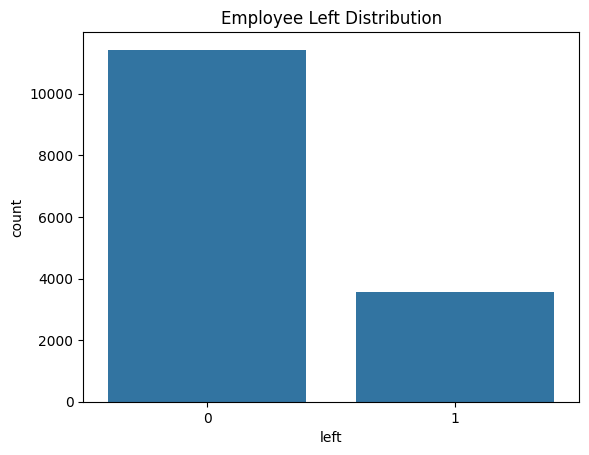

In [6]:
df['left'].value_counts()
sns.countplot(x= 'left', data=df)
plt.title("Employee Left Distribution")
plt.show()

**SECTION 4: Exploratory Data Analysis (EDA)**

4.1 Correlation Heatmap

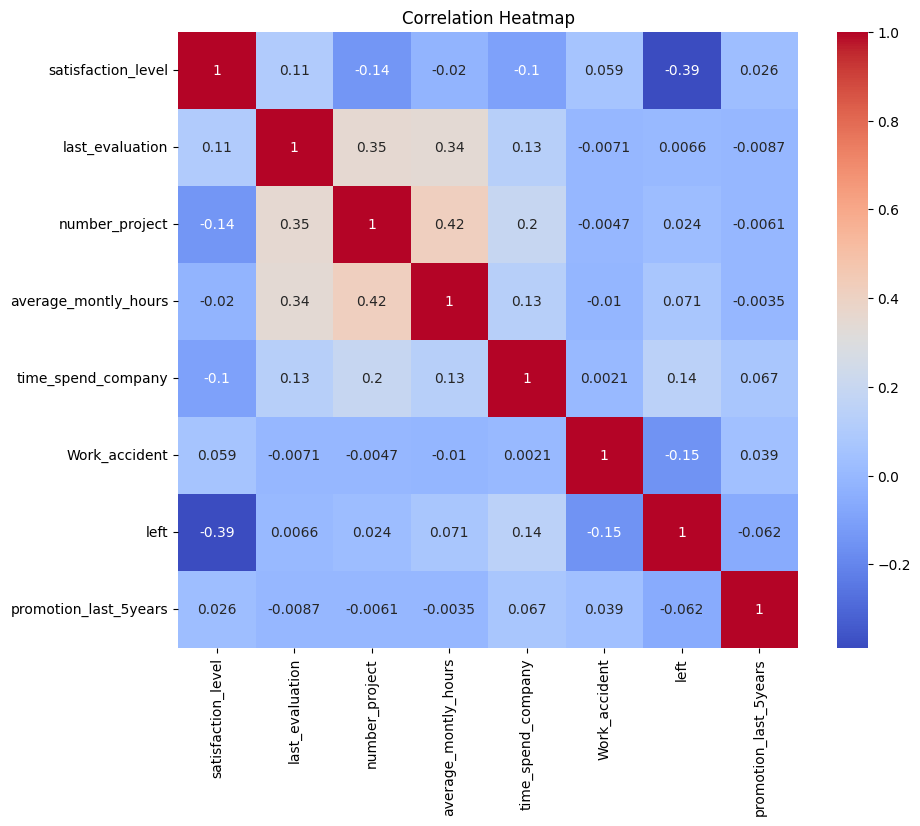

In [7]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()



Strong negative correlation:
satisfaction_level → left

Positive correlation:
time_spend_company → left
average_monthly_hours → left
number_project → left

**4.2 Distribution Plots**

Satisfaction Level

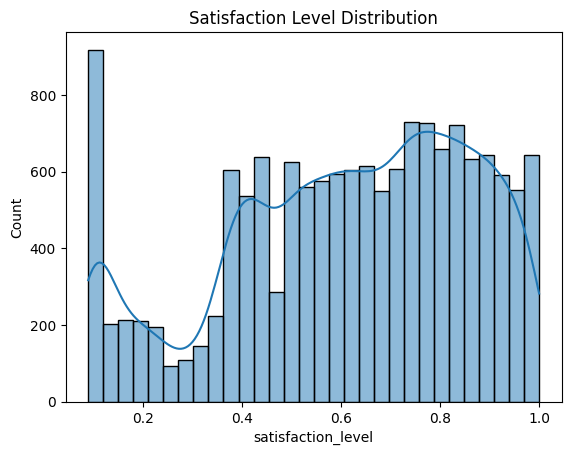

In [8]:
sns.histplot(df['satisfaction_level'], kde=True)
plt.title("Satisfaction Level Distribution")
plt.show()

Last Evaluation

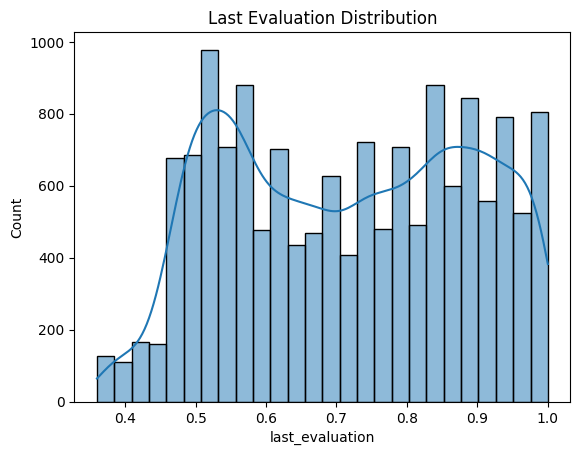

In [9]:
sns.histplot(df['last_evaluation'], kde=True)
plt.title("Last Evaluation Distribution")
plt.show()


Monthly Hours

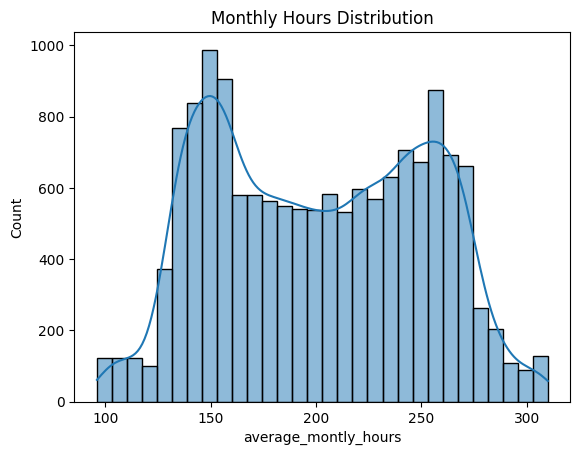

In [10]:
sns.histplot(df['average_montly_hours'], kde=True)
plt.title("Monthly Hours Distribution")
plt.show()

**4.3 Project Count vs Left**

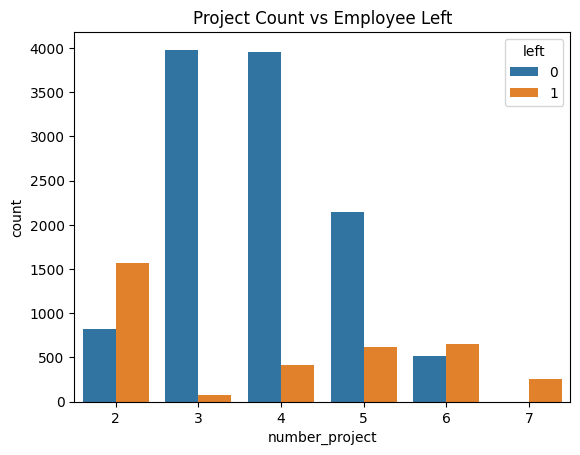

In [11]:
sns.countplot(x='number_project' , hue='left',  data=df)
plt.title("Project Count vs Employee Left")
plt.show()

Employees with:

Too few projects → bored → leave

Too many projects → burnout → leave

**SECTION 5: Clustering Employees Who Left**

Filter employees who left

In [12]:
left_emp = df[df['left']==1][['satisfaction_level', 'last_evaluation']]

Apply KMeans

In [13]:
kmeans = KMeans(n_clusters = 3, random_state=42)
left_emp['cluster'] = kmeans.fit_predict(left_emp)

Visualize Clusters

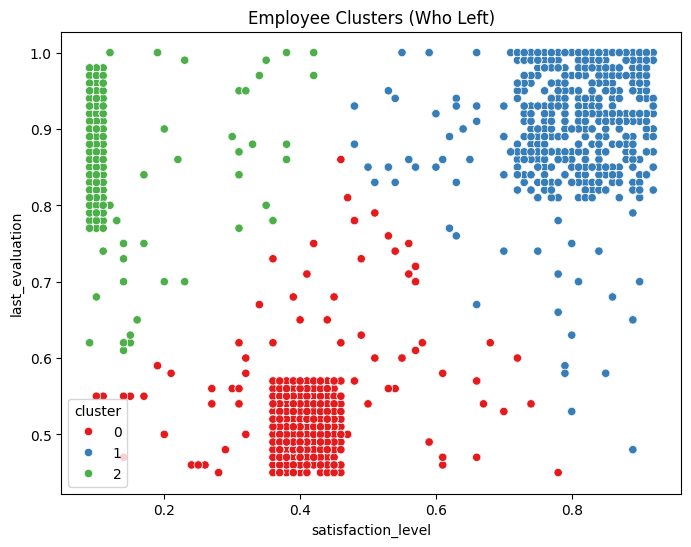

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='satisfaction_level',
    y='last_evaluation',
    hue='cluster',
    data=left_emp,
    palette='Set1'
)

plt.title("Employee Clusters (Who Left)")
plt.show()


Typical clusters:

Cluster 0:

Low satisfaction

Low evaluation
→ disengaged employees

Cluster 1:

Low satisfaction

High evaluation
→ overworked employees

Cluster 2:

Moderate satisfaction
→ unstable employees

**SECTION 6: Data Preprocessing**

Separate categorical and numeric

In [22]:
cat_cols= ['sales' , 'salary'] #categorical columns

num_cols = df.columns.drop(cat_cols) #Numeric columns

In [21]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales', 'salary'],
      dtype='object')

One-hot encoding

In [ ]:
df_cat = pd.get_dummies(df[cat_cols], drop_first=True)
df_num = df[num_cols] #numeric dataframe

df_final = pd.concat([df_num, df_cat], axis=1) #combine both
df_final.head()



,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [28]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales_RandD            14999 non-null  bool   
 9   sales_accounting       14999 non-null  bool   
 10  sales_hr               14999 non-null  bool   
 11  sales_management       14999 non-null  bool   
 12  sales_marketing        14999 non-null  bool   
 13  sales_product_mng      14999 non-null  bool   
 14  sales_sales            14999 non-null  bool   
 15  sa

**SECTION 7: Train-Test Split**

In [30]:
X = df_final.drop('left' , axis = 1)
y = df_final ['left']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
   test_size=0.2,
   random_state= 123,
    stratify=y
)

**SECTION 8: Handle Class Imbalance using SMOTE**

In [31]:
smote = SMOTE(random_state=123)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: left
0    9142
1    2857
Name: count, dtype: int64
After SMOTE: left
0    9142
1    9142
Name: count, dtype: int64


**SECTION 9: Model Training with 5-Fold Cross Validation**

Create function:

In [32]:
def train_model(model, X, y, name): #function definition
  skf =  StratifiedKFold(n_splits=5) #create stratified  5-Fold object
  y_pred =  cross_val_predict(model, X, y, cv=skf)
  print(f"\n{name} Classification Report")
  print(classification_report(y, y_pred))
  return model.fit(X,y)

**Train Logistic Regression**

In [34]:
lr = LogisticRegression(max_iter=1000)
lr_model = train_model(lr, X_train_sm, y_train_sm, "Logistic Regression")



Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      9142
           1       0.78      0.82      0.80      9142

    accuracy                           0.79     18284
   macro avg       0.80      0.79      0.79     18284
weighted avg       0.80      0.79      0.79     18284



**Train Random Forest**

In [35]:
rf = RandomForestClassifier(n_estimators=200)
rf_model =  train_model(rf, X_train_sm, y_train_sm, "Random Forest")


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      9142
           1       1.00      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.98      0.98      0.98     18284
weighted avg       0.98      0.98      0.98     18284



**Train Gradient Boosting**

In [37]:
gb = GradientBoostingClassifier()
gb_model = train_model(gb, X_train_sm, y_train_sm, "Gradient Boosting")


Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      9142
           1       0.98      0.95      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96     18284
weighted avg       0.96      0.96      0.96     18284



**Why Random Forest is Best**
Precision = 1.00 (No false alarms-Every employee predicted to leave actually left), Recall=0.97(97% of employees who left were correctly indentified)
F1 Score=0.98(Perfect balane of Precision and Recall)
Accuracy = 98%(overall excellent performance)

**Gradient Boosting**-Slightly lower Recall and Precision than Random Forest.Misses more leaving employees.


Random Forest model can reliably predict employee turnover and help HR take proactive retention actions.

**SECTION 10: ROC Curve Comparison**

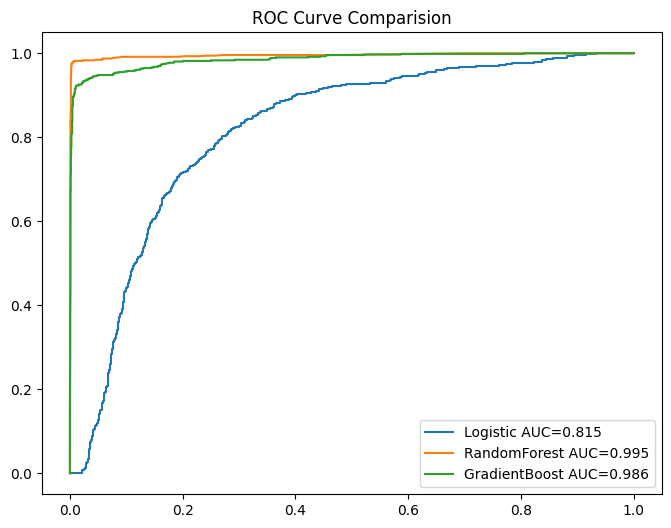

In [41]:
models = {
    "Logistic": lr_model,
    "RandomForest": rf_model,
    "GradientBoost": gb_model

}
plt.figure(figsize=(8,6))
for name, model in models.items():
  y_prob = model.predict_proba(X_test)[:,1]
  fpr, tpr, _ = roc_curve(y_test, y_prob)
  auc = roc_auc_score(y_test, y_prob)
  plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

plt.legend()
plt.title("ROC Curve Comparision")
plt.show()


**SECTION 11: Confusion Matrix**

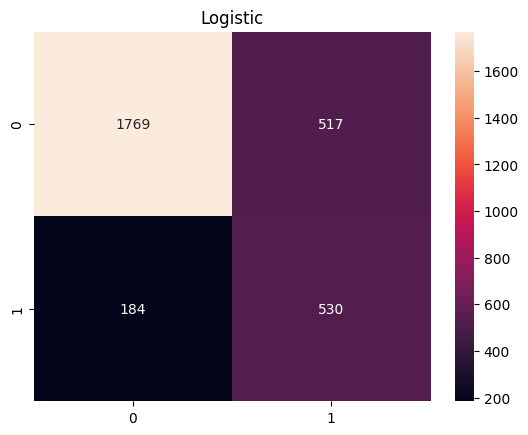

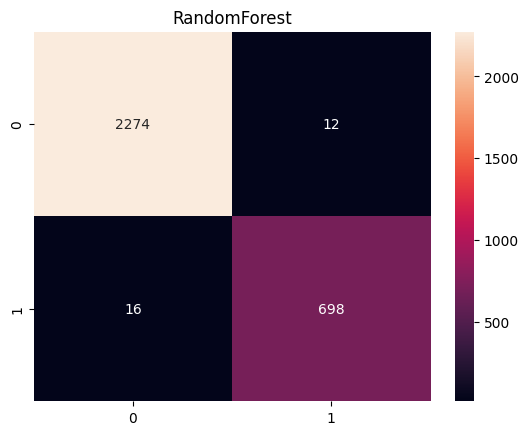

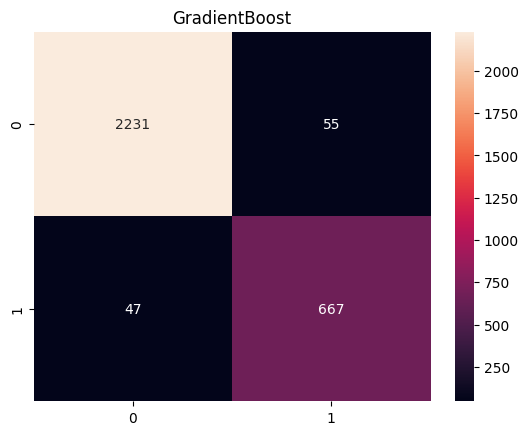

In [42]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name)
    plt.show()


**SECTION 12: Best Model Selection**

In [46]:
best_model = rf_model

print("Best Model Selected: Random Forest Classifier")


Best Model Selected: Random Forest Classifier


**SECTION 14: Predict Turnover Probability**

This predicts probability of employee leaving.

In [47]:
# Predict probabilities
turnover_prob = best_model.predict_proba(X_test)[:,1]

# Create DataFrame
prob_df = pd.DataFrame({

    "Turnover Probability": turnover_prob

})

prob_df.head()


,Turnover Probability
0,0.000
1,0.600
2,0.035
3,0.005
4,0.000


**SECTION 15: Risk Zone Classification**

Categorize employees into:
- Safe Zone
- Low Risk
- Medium Risk
- High Risk

In [48]:
# Risk classification function
def classify_risk(prob):

    if prob < 0.20:
        return "Safe Zone (Green)"

    elif prob < 0.60:
        return "Low Risk (Yellow)"

    elif prob < 0.90:
        return "Medium Risk (Orange)"

    else:
        return "High Risk (Red)"


# Apply classification
prob_df["Risk Zone"] = prob_df["Turnover Probability"].apply(classify_risk)

prob_df.head()


,Turnover Probability,Risk Zone
0,0.000,Safe Zone (Green)
1,0.600,Medium Risk (Orange)
2,0.035,Safe Zone (Green)
3,0.005,Safe Zone (Green)
4,0.000,Safe Zone (Green)


**SECTION 16: Risk Zone Distribution**

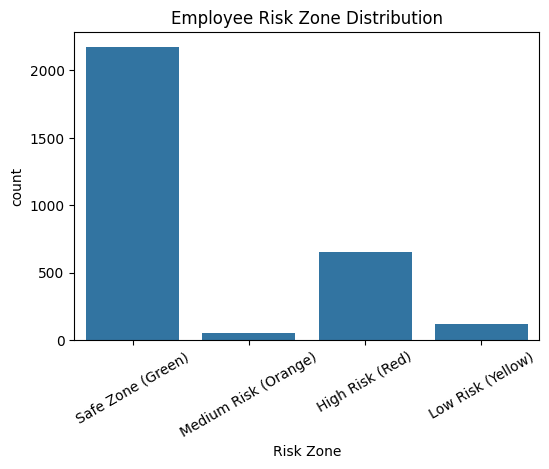

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(x="Risk Zone", data=prob_df)

plt.title("Employee Risk Zone Distribution")

plt.xticks(rotation=30)

plt.show()


**SECTION 17: Retention Strategy Recommendation**

Add retention action column.

In [50]:
def retention_strategy(zone):

    if zone == "Safe Zone (Green)":
        return "Maintain engagement and recognize performance"

    elif zone == "Low Risk (Yellow)":
        return "Provide career growth opportunities"

    elif zone == "Medium Risk (Orange)":
        return "Review workload, salary, and job satisfaction"

    else:
        return "Immediate HR intervention required"


prob_df["Retention Strategy"] = prob_df["Risk Zone"].apply(retention_strategy)

prob_df.head()


,Turnover Probability,Risk Zone,Retention Strategy
0,0.000,Safe Zone (Green),Maintain engagement and recognize performance
1,0.600,Medium Risk (Orange),"Review workload, salary, and job satisfaction"
2,0.035,Safe Zone (Green),Maintain engagement and recognize performance
3,0.005,Safe Zone (Green),Maintain engagement and recognize performance
4,0.000,Safe Zone (Green),Maintain engagement and recognize performance


**SECTION 18: Save Final Results**

In [51]:
prob_df.to_csv("employee_turnover_predictions.csv", index=False)

print("Predictions saved successfully")


Predictions saved successfully
